## Decision Tree
Train a decision tree on the original census data using the same preprocessing pipeline style as the other notebooks.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
col_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df = pd.read_csv(
    "census+income/adult.data",
    header=None,
    names=col_names,
    sep=r",\s*",
    engine="python",
    na_values="?"
)

df = df.drop(columns=["fnlwgt"])
df["income"] = df["income"].astype(str).str.replace(".", "", regex=False).str.strip()
y = (df["income"] == ">50K").astype(int)
X = df.drop(columns=["income"])

In [3]:
numeric_features = [
    "age", "education_num", "capital_gain", "capital_loss", "hours_per_week"
]

categorical_features = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=11,
    stratify=y
)

tree_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("tree", DecisionTreeClassifier(max_depth=10, random_state=11))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_cm = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)
print("\nDecision Tree confusion matrix:\n", tree_cm)
print("\nDecision Tree classification report:\n", classification_report(y_test, y_pred_tree))

# Export confusion matrix and probabilities for later comparison
os.makedirs("exports", exist_ok=True)
dt_cm_path = os.path.join("exports", "decision_tree_confusion_matrix.csv")
np.savetxt(dt_cm_path, tree_cm, fmt="%d", delimiter=",")

dt_probs_path = os.path.join("exports", "decision_tree_probs.csv")
np.savetxt(dt_probs_path, np.column_stack([y_test.to_numpy(), y_proba_tree]), delimiter=",")

print(f"Saved Decision Tree confusion matrix to: {dt_cm_path}")
print(f"Saved Decision Tree probabilities to: {dt_probs_path}")

Decision Tree Accuracy: 0.8568971870777545

Decision Tree confusion matrix:
 [[5864  317]
 [ 848 1112]]

Decision Tree classification report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      6181
           1       0.78      0.57      0.66      1960

    accuracy                           0.86      8141
   macro avg       0.83      0.76      0.78      8141
weighted avg       0.85      0.86      0.85      8141

Saved Decision Tree confusion matrix to: exports\decision_tree_confusion_matrix.csv


In [5]:
processed_feature_names = tree_model.named_steps["preprocess"].get_feature_names_out()
importances = tree_model.named_steps["tree"].feature_importances_

feature_importance_df = pd.DataFrame({
    "processed_feature": processed_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top processed feature importances:")
print(feature_importance_df.head(20).to_string(index=False))

def tree_original_column(processed_feature_name):
    suffix = processed_feature_name.split("__", 1)[-1]

    if suffix in numeric_features:
        return suffix

    for col in sorted(categorical_features, key=len, reverse=True):
        if suffix == col or suffix.startswith(f"{col}_"):
            return col

    return suffix

feature_importance_df["original_column"] = feature_importance_df["processed_feature"].apply(tree_original_column)
column_importance_df = (
    feature_importance_df
    .groupby("original_column", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print("\nGrouped feature importances by original column:")
print(column_importance_df.to_string(index=False))

Top processed feature importances:
                     processed_feature  importance
cat__marital_status_Married-civ-spouse    0.376453
                    num__education_num    0.208025
                     num__capital_gain    0.190990
                     num__capital_loss    0.071644
                              num__age    0.050839
                   num__hours_per_week    0.035872
       cat__occupation_Exec-managerial    0.007343
         cat__occupation_Other-service    0.007320
       cat__workclass_Self-emp-not-inc    0.006148
                cat__relationship_Wife    0.004605
        cat__occupation_Prof-specialty    0.003412
                       cat__sex_Female    0.002766
       cat__occupation_Farming-fishing    0.002605
              cat__workclass_State-gov    0.002403
                cat__workclass_Private    0.002240
     cat__native_country_United-States    0.001939
              cat__workclass_Local-gov    0.001936
            cat__education_Prof-school    0.001

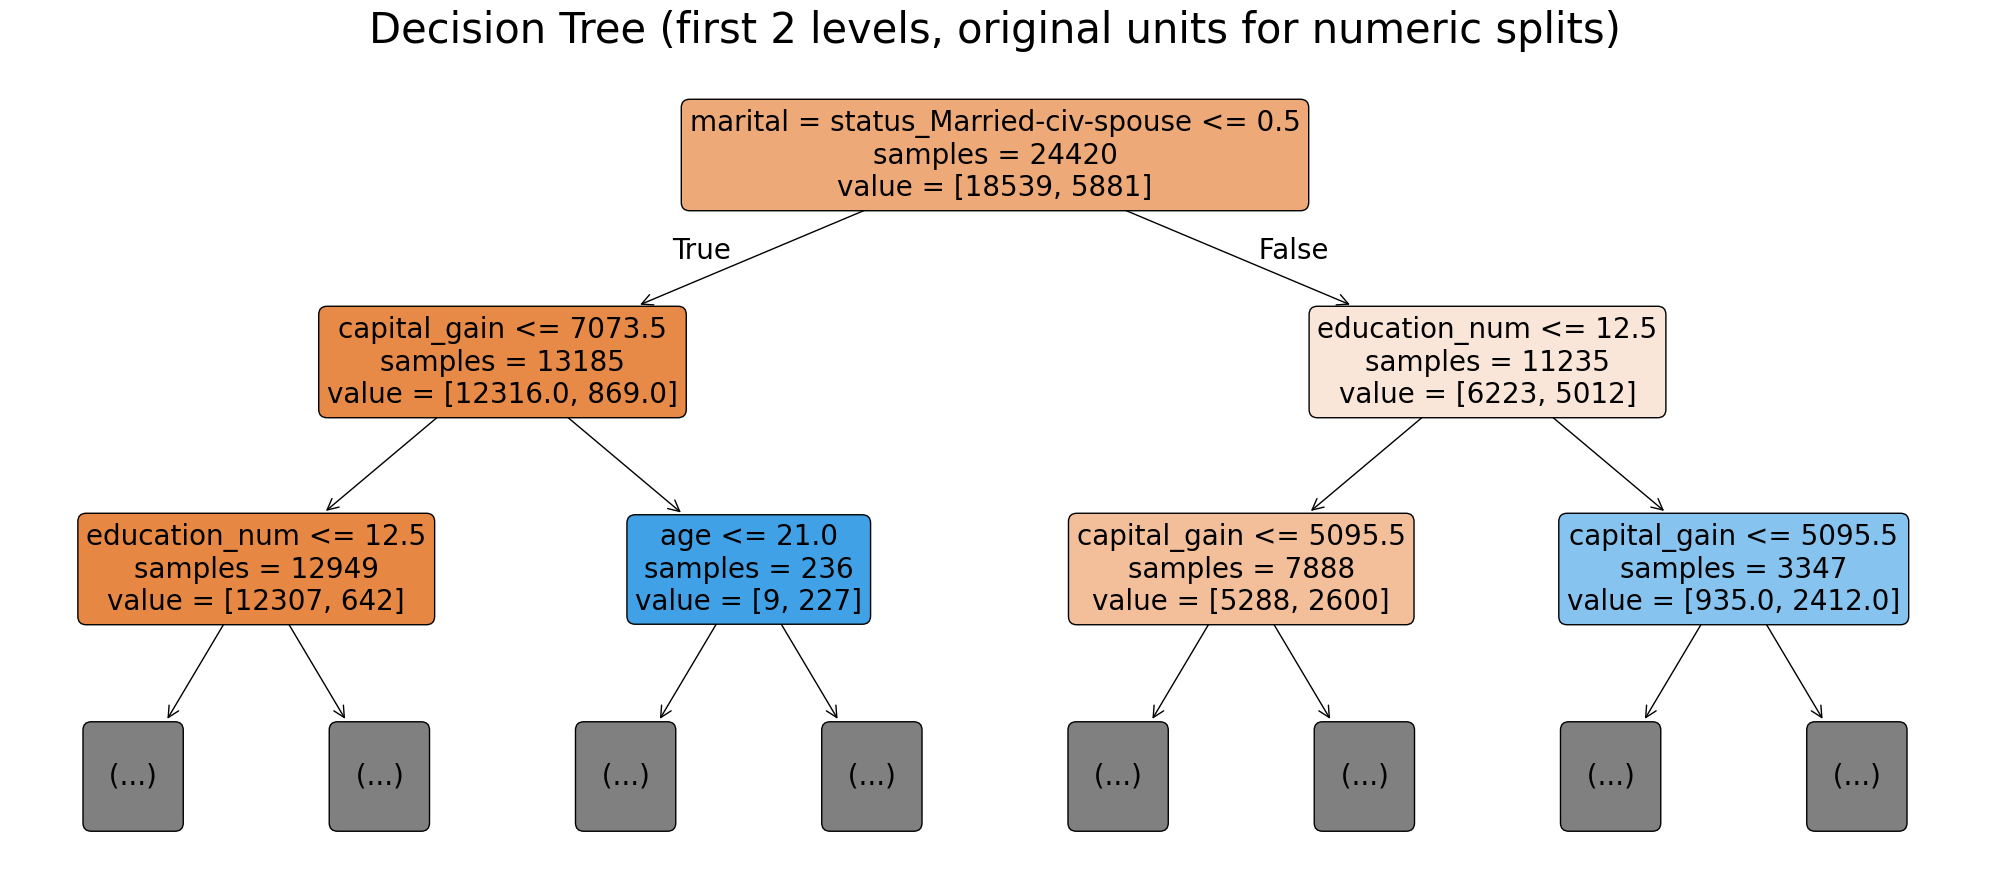

In [6]:
from copy import deepcopy

# Make a display-only copy of the tree with numeric split thresholds converted
# back to the original feature scale.
display_tree = deepcopy(tree_model.named_steps["tree"])
scaler = tree_model.named_steps["preprocess"].named_transformers_["num"].named_steps["scaler"]
processed_feature_names = tree_model.named_steps["preprocess"].get_feature_names_out()

def pretty_feature_name(processed_feature_name):
    suffix = processed_feature_name.split("__", 1)[-1]

    if suffix in numeric_features:
        return suffix

    if "_" in suffix:
        original_column, category = suffix.split("_", 1)
        return f"{original_column} = {category}"

    return suffix

for node_index in range(display_tree.tree_.node_count):
    feature_index = display_tree.tree_.feature[node_index]
    if feature_index < 0:
        continue

    processed_name = processed_feature_names[feature_index]
    original_name = processed_name.split("__", 1)[-1]

    if original_name in numeric_features:
        numeric_index = numeric_features.index(original_name)
        display_tree.tree_.threshold[node_index] = (
            display_tree.tree_.threshold[node_index] * scaler.scale_[numeric_index]
            + scaler.mean_[numeric_index]
        )

plt.figure(figsize=(20, 9))
plot_tree(
    display_tree,
    feature_names=[pretty_feature_name(name) for name in processed_feature_names],
    filled=True,
    max_depth=2,
    fontsize=20,
    impurity=False,
    rounded=True
)
plt.title("Decision Tree (first 2 levels, original units for numeric splits)", fontsize=30)
plt.tight_layout()
plt.show()

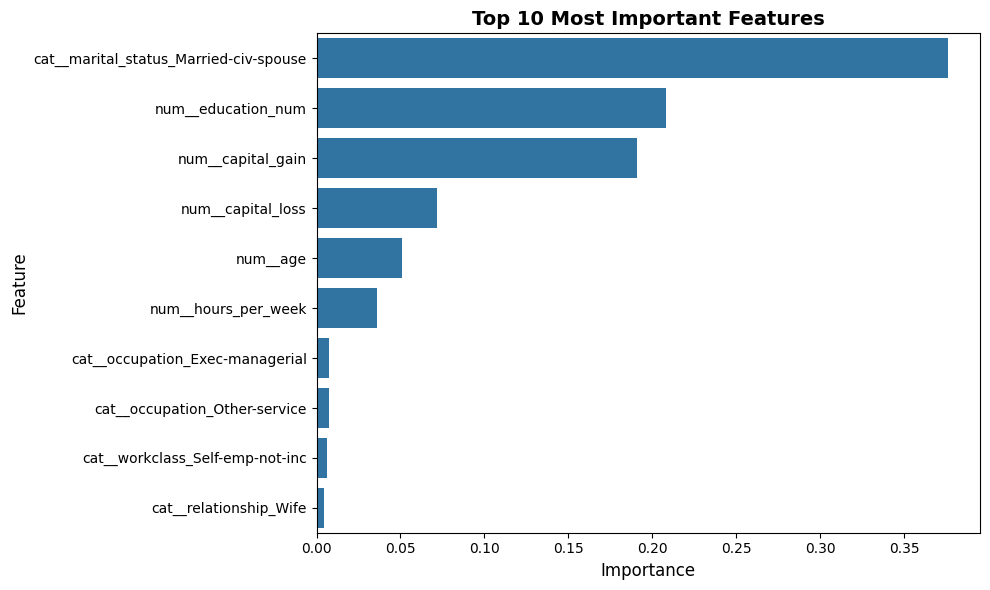

Top 10 most important processed features:


,processed_feature,importance
31,cat__marital_status_Married-civ-spouse,0.376453
1,num__education_num,0.208025
2,num__capital_gain,0.190990
3,num__capital_loss,0.071644
0,num__age,0.050839
4,num__hours_per_week,0.035872
39,cat__occupation_Exec-managerial,0.007343
43,cat__occupation_Other-service,0.007320
10,cat__workclass_Self-emp-not-inc,0.006148
55,cat__relationship_Wife,0.004605


In [7]:
top_n = 10

# Get top features from processed feature importance.
sorted_by_importance = feature_importance_df.sort_values("importance", ascending=False)
top_features = sorted_by_importance.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_features.sort_values("importance", ascending=False),
    x="importance",
    y="processed_feature",
    color="#1f77b4",
    ax=ax
)

ax.set_title("Top 10 Most Important Features", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)

plt.tight_layout()
plt.show()

print("Top 10 most important processed features:")
display(top_features[["processed_feature", "importance"]])